In [1]:
import rmgpy.chemkin
import os

import cantera as ct
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import rmgpy.solver
import rmgpy.rmg.listener
import rmgpy.rmg.settings

import rmgpy.tools.plot


In [2]:
chemkin = 'rmg_run/short-gas.inp'
chemkin_surf = 'rmg_run/short-surface.inp'
spec_dict = 'rmg_run/species_dictionary.txt'

mech_yaml = 'rmg_run/short.yaml'

gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=chemkin_surf)

# Define reactor settings to be used for both simulations

In [195]:
x_O2 = 1e-5
x_CH4 = 1.2e-5
T = rmgpy.quantity.Quantity((700, 'K'))
P = rmgpy.quantity.Quantity((1, 'atm'))

surface_volume_ratio = rmgpy.quantity.Quantity((1.0, "m^-1"))
surface_site_density = rmgpy.quantity.Quantity((surf.site_density, "kmol/m^2"))  # read from Cantera yaml just to be sure these match

termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((1.0, 's')))

# Set up the RMG simulation

In [196]:
def get_i_thing_rmg(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False

Ar = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[Ar]'), species_list)]
CH4 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='C'), species_list)]
O2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[O][O]'), species_list)]
H2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[H][H]'), species_list)]
H2O = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='O'), species_list)]
X = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='*'), species_list)]

initial_gas_mole_fractions = {O2: x_O2, CH4: x_CH4, Ar: 1.0 - x_O2 - x_CH4}
initial_surface_coverages = {X: 1.0}

reaction_system = rmgpy.solver.surface.SurfaceReactor(
    T,
    P,
    n_sims=1,
    initial_gas_mole_fractions=initial_gas_mole_fractions,
    initial_surface_coverages=initial_surface_coverages,
    surface_volume_ratio=surface_volume_ratio,
    surface_site_density=surface_site_density,
    termination=[termination],
)

output_directory = './'
os.makedirs(os.path.join(output_directory, 'solver'), exist_ok=True)
reaction_system_index = 0
reaction_system.attach(rmgpy.rmg.listener.SimulationProfileWriter(output_directory, reaction_system_index, species_list))  # to save results

simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings(tol_move_to_core=1e5)  # tol_move_to_core isn't set by default which causes an error

### Run the simulation and retrieve the results from the CSV file

In [197]:
reaction_system.simulate(
    core_species=species_list,
    core_reactions=reaction_list,
    edge_species=[],
    edge_reactions=[],
    surface_species=[],
    surface_reactions=[],
    model_settings=model_settings,
    simulator_settings=simulator_settings,
    sensitivity=False,
    sens_worksheet=[],
)

# retrieve the data from the csv
# You could use pandas to get it more directly, but this is fine
simulation_outfile = os.path.join(output_directory, 'solver', f'simulation_1_{len(species_list):d}.csv')
times, data = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels = [d.label for d in data]

In [198]:
simulation_outfile

'./solver/simulation_1_17.csv'

# Run the simulation in Cantera

In [199]:
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

# check that the species and reactions match up between RMG and Cantera
assert len(species_list) == gas.n_species + surf.n_species
assert len(reaction_list) == gas.n_reactions + surf.n_reactions

for i in range(gas.n_species):
    assert str(species_list[i].to_chemkin()) == str(gas.species_names[i])
for i in range(surf.n_species):
    assert str(species_list[i + gas.n_species].to_chemkin()) == str(surf.species_names[i])


def same_reaction(rmg_rxn, ct_rxn):
    # really hacky way to do this, but whatever
    rmg_r = set([str(x.to_chemkin()) for x in rmg_rxn.reactants])
    rmg_p = set([str(x.to_chemkin()) for x in rmg_rxn.products])
    rmg_r = rmg_r - set(['Ar'])
    rmg_p = rmg_p - set(['Ar'])
    rmg_val = list(set(sorted(list(rmg_r) + list(rmg_p))))
    
    ct_r = set(ct_rxn.reactants.keys())
    ct_p = set(ct_rxn.products.keys())
    ct_val = list(set(sorted(list(ct_r) + list(ct_p))))
    return ct_val == rmg_val

for i in range(gas.n_reactions):
    assert same_reaction(reaction_list[i], gas.reactions()[i])
for i in range(surf.n_reactions):
    assert same_reaction(reaction_list[i + gas.n_reactions], surf.reactions()[i])


In [200]:
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

REACTOR_VOLUME = 8.314 * T.value_si / ct.one_atm
initial_gas_mole_fractions_ct = {x.to_chemkin(): v for x, v in initial_gas_mole_fractions.items()}
initial_surface_coverages_ct = {x.to_chemkin(): v for x, v in initial_surface_coverages.items()}

REACTOR_AREA = REACTOR_VOLUME * surface_volume_ratio.value_si

gas.TPX = T.value_si, P.value_si, initial_gas_mole_fractions_ct
gas_reactor = ct.IdealGasReactor(gas, energy='off')
gas_reactor.volume = REACTOR_VOLUME

surf.TP = T.value_si, P.value_si
surf.coverages = initial_surface_coverages_ct

surf_reactor = ct.ReactorSurface(surf, gas_reactor)
surf_reactor.area = REACTOR_AREA

sim = ct.ReactorNet([gas_reactor])

times_ct = [sim.time]
volumes = [gas_reactor.volume]
pressures = [gas.P]
temperatures = [gas.T]
surf_concs = [surf.concentrations]
gas_mol_fracs = [gas.X]
surf_cov = [surf_reactor.coverages]
while sim.time < termination.time.value_si:
    sim.step()
    times_ct.append(sim.time)
    volumes.append(gas_reactor.volume)
    pressures.append(gas.P)
    temperatures.append(gas.T)
    surf_cov.append(surf_reactor.coverages)
    surf_concs.append(surf.concentrations)
    # gas_mol_fracs.append(gas.X.copy())
    gas_mol_fracs.append(gas.X)

times_ct = np.array(times_ct)
volumes = np.array(volumes)
pressures = np.array(pressures)
temperatures = np.array(temperatures)
surf_cov = np.array(surf_cov)
surf_concs = np.array(surf_concs)
gas_mol_fracs = np.array(gas_mol_fracs)


# Plot the differences

Text(0.5, 1.0, 'Surface Coverage vs. Time')

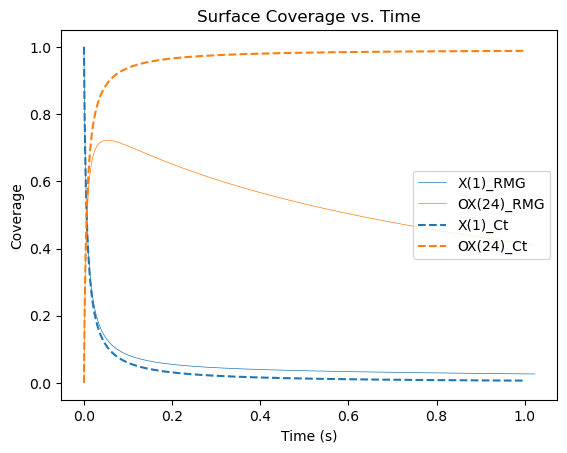

In [202]:
# plot surface coverages
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
X = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='*'), species_list)]
OX = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='O=*'), species_list)]
# HX = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[H]*'), species_list)]
# CH3X = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[H]*'), species_list)]

conc_X = data[data_labels.index(X.to_chemkin())].data  # mols of adsorbate
conc_OX = data[data_labels.index(OX.to_chemkin())].data  # mols of adsorbate

total_sites = surface_site_density.value_si * (reaction_system.V * reaction_system.surface_volume_ratio.value_si)
coverage_X = conc_X / total_sites
coverage_OX = conc_OX / total_sites

plt.plot(times.data, coverage_X, label=X.to_chemkin()+'_RMG', color=colors[0], linewidth=0.5)
plt.plot(times.data, coverage_OX, label=OX.to_chemkin()+'_RMG', color=colors[1], linewidth=0.5)

plt.plot(times_ct, surf_cov[:, surf.species_names.index(X.to_chemkin())], label=X.to_chemkin()+'_Ct', color=colors[0], linestyle='dashed')
plt.plot(times_ct, surf_cov[:, surf.species_names.index(OX.to_chemkin())], label=OX.to_chemkin()+'_Ct', color=colors[1], linestyle='dashed')

plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Coverage')
plt.title('Surface Coverage vs. Time')

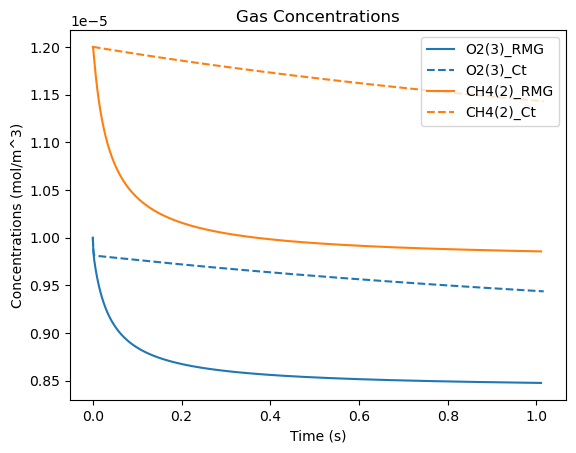

In [194]:
# plot gas results -- here we use the Cantera gas mol fractions with the understanding that we always ~1 mol of gas
conc_O2 = data[data_labels.index(O2.to_chemkin())].data
conc_CH4 = data[data_labels.index(CH4.to_chemkin())].data

plt.plot(times.data, conc_O2, label=O2.to_chemkin()+'_RMG', color=colors[0])
plt.plot(times_ct, gas_mol_fracs[:, gas.species_names.index(O2.to_chemkin())], label=O2.to_chemkin()+'_Ct', linestyle='dashed', color=colors[0])

plt.plot(times.data, conc_CH4, label=CH4.to_chemkin()+'_RMG', color=colors[1])
plt.plot(times_ct, gas_mol_fracs[:, gas.species_names.index(CH4.to_chemkin())], label=CH4.to_chemkin()+'_Ct', linestyle='dashed', color=colors[1])

plt.title('Gas Concentrations')
plt.xlabel('Time (s)')
plt.ylabel('Concentrations (mol/m^3)')
plt.legend()

# Inspect the reactor settings

In [118]:
print('Reactor volumes (m^3)')
print('RMG:\t\t', reaction_system.V)  # m^3
print('Cantera:\t', gas_reactor.volume)  # m^3

Reactor volumes (m^3)
RMG:		 0.057440221070811745
Cantera:	 0.05743696027633852


In [119]:
print('Reactor Areas (m^2)')
print('RMG:\t\t', reaction_system.V * reaction_system.surface_volume_ratio.value_si)  # m^2
print('Cantera:\t', surf_reactor.area)  # m^2

Reactor Areas (m^2)
RMG:		 0.057440221070811745
Cantera:	 0.05743696027633852


In [120]:
print('Surface site densities (mols sites / m^2)')
print('RMG:\t\t', reaction_system.surface_site_density.value_si)  # mols / m^2
print('Cantera:\t', surf.site_density * 1000)  # have to convert from Cantera's kmol/m^2

Surface site densities (mols sites / m^2)
RMG:		 2.4829999999999998e-05
Cantera:	 2.4829999999999998e-05


In [121]:
print('Pressure (Pa)')
print('RMG:\t\t', reaction_system.P_initial.value_si)
print('Cantera:\t', gas.P)

Pressure (Pa)
RMG:		 101325.0
Cantera:	 101324.94274965336


In [122]:
print('Temperature (K)')
print('RMG:\t\t', reaction_system.T.value_si)
print('Cantera:\t', gas.T)

Temperature (K)
RMG:		 700.0
Cantera:	 700.0
